In [ ]:
import pandas as pd
import polars as pl
import statsmodels.api as sm
from polars import col, when, lit
import polars.selectors as cs
from plotnine import *
from mizani.formatters import percent_format

In [ ]:
# df = pd.read_csv("Data/data.csv")
df = pl.read_csv("Data/data.csv")

# Cleanup
df = (
    df.with_columns(
        (col("Attrition").replace({"Yes": 1, "No": 0})).cast(pl.Int64).alias("AttritionBinary")
    )
    # PerformanceRating -- seems to only be 3 or 4?
    .drop("EmployeeCount", "Over18", "StandardHours", "EmployeeNumber", "PerformanceRating")
)


In [ ]:
df.describe()

In [ ]:
df.drop("Attrition", "AttritionBinary")

In [ ]:
df.drop("Attrition", "AttritionBinary").to_numpy()  # predictor variables


In [ ]:
# X = df[['DistanceFromHome', 'Education', 'MonthlyIncome', "YearsSinceLastPromotion"]].to_numpy()  # predictor variables
X = df.select(cs.numeric()).drop("AttritionBinary").to_numpy()  # predictor variables

feature_names = ['const'] + df.select(cs.numeric()).drop("AttritionBinary").columns

y = df['AttritionBinary'].to_numpy()                                # binary outcome (0/1)

# Add intercept (statsmodels doesn't add one automatically)
X = sm.add_constant(X)

model = sm.Logit(y, X)
result = model.fit()

print(result.summary(xname=feature_names))



In [177]:


ci = result.conf_int()#.values

# MAKE SURE CONFIDENCE INTERVALS MAKE SENSE
coefficients = (
    pd.DataFrame({
        'feature': feature_names,
        'coef': result.params,
        'se': result.bse,
        'ci_lower': ci[:, 0],
        'ci_upper': ci[:, 1],
        'pvalue': result.pvalues,
    })
    .assign(abs_coef=lambda d: d['coef'].abs())
    .sort_values('abs_coef', ascending=False)
)

coefficients = (
    pl.from_pandas(coefficients)
    .with_columns(
        (col("pvalue") < .05).alias("significant")
    )
)

coefficient_features_ordered = coefficients.sort('coef')['feature'].to_list()

coefficients = coefficients.with_columns(col("feature").cast(pl.Enum(coefficient_features_ordered)))

# pl.Config(tbl_rows=50)
coefficients



feature,coef,se,ci_lower,ci_upper,pvalue,abs_coef,significant
enum,f64,f64,f64,f64,f64,f64,bool
"""const""",4.324174,1.097161,2.173778,6.47457,0.000081,4.324174,true
"""StockOptionLevel""",-0.521992,0.10508,-0.727944,-0.316039,6.7792e-7,0.521992,true
"""JobInvolvement""",-0.483952,0.107912,-0.695455,-0.272449,0.000007,0.483952,true
"""JobSatisfaction""",-0.302994,0.071049,-0.442248,-0.16374,0.00002,0.302994,true
"""PerformanceRating""",0.300743,0.346768,-0.378909,0.980396,0.385791,0.300743,false
"""EnvironmentSatisfaction""",-0.300679,0.071228,-0.440283,-0.161076,0.000024,0.300679,true
"""WorkLifeBalance""",-0.240051,0.106663,-0.449107,-0.030995,0.024414,0.240051,true
"""TrainingTimesLastYear""",-0.158462,0.062402,-0.280767,-0.036158,0.011104,0.158462,true
"""RelationshipSatisfaction""",-0.15073,0.07239,-0.292611,-0.008848,0.037325,0.15073,true


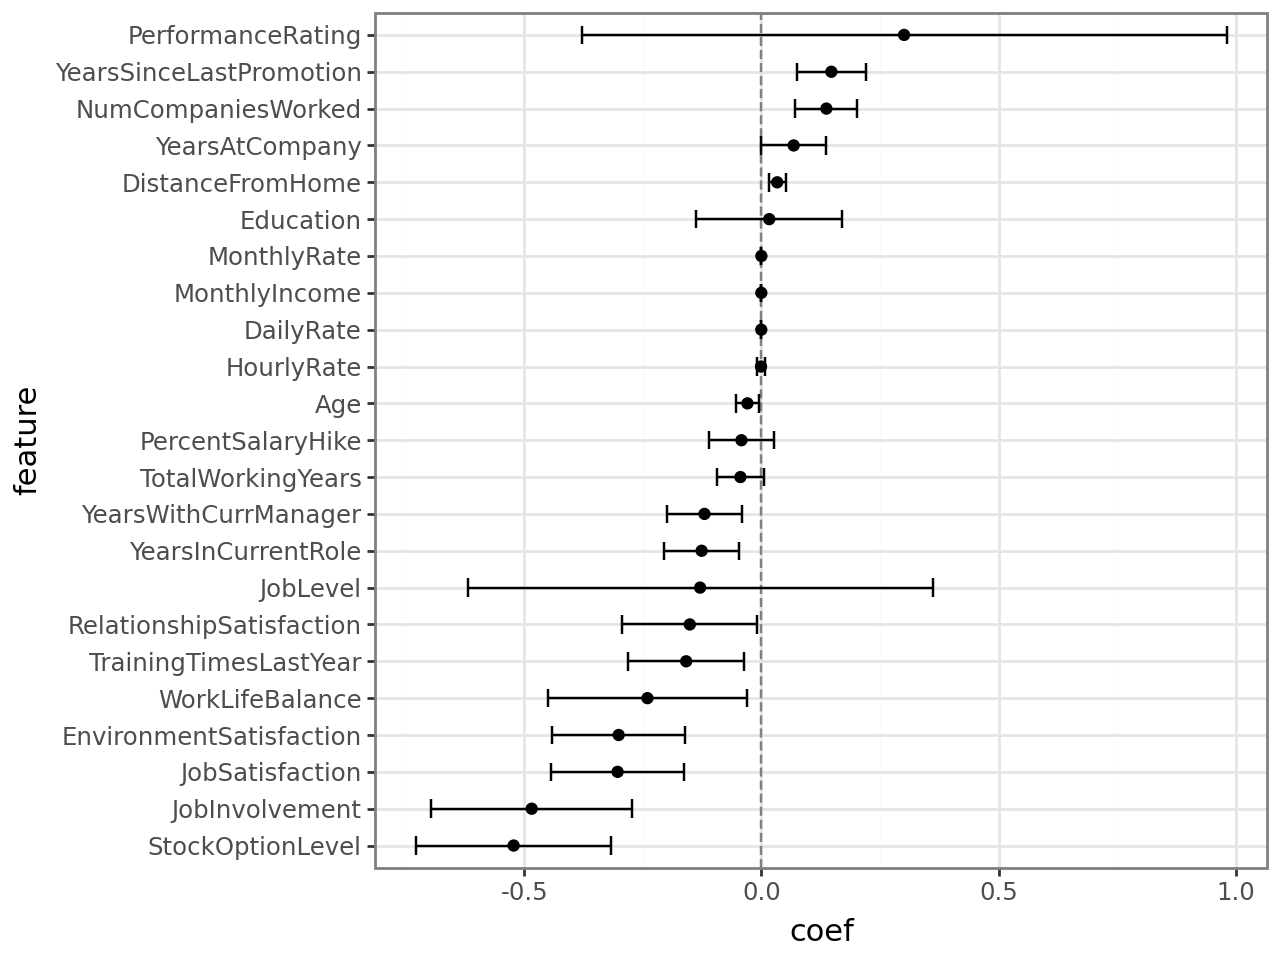

In [178]:
(
    ggplot(
        data=coefficients.filter(col("feature") != "const"),
        mapping=aes(x="feature", y="coef")
    )
    + geom_hline(yintercept=0, linetype="dashed", color="grey")
    + geom_point()
    + geom_errorbar(mapping=aes(ymin="ci_lower", ymax="ci_upper"))
    + coord_flip()
    + theme_bw()
)

In [ ]:
(
    ggplot(data=df, mapping=aes(x="MonthlyIncome", y="AttritionBinary"))
    + geom_point(alpha=.1)
    + geom_smooth()
)

In [ ]:

# EmployeeCount
# Over18
# StandardHours

# df["AttritionBinary"].mean()
correlation_matrix = (
    df
        .select(cs.numeric())
        .corr()
        .select("AttritionBinary", cs.all() - cs.by_name('AttritionBinary'))
        # Add feature names as a column
        .insert_column(0, pl.Series('Feature', df.select(cs.numeric()).columns))
        # .sort("AttritionBinary")

)
ordered_cats = correlation_matrix.sort('AttritionBinary')['Feature'].to_list()

correlation_matrix = (
    correlation_matrix
        .with_columns(
            col('Feature').cast(pl.Enum(ordered_cats))
        )
        .sort("Feature")
)

correlation_matrix

In [ ]:
correlation_matrix_for_plot = (
    correlation_matrix
        .filter(col("Feature") != "AttritionBinary")
        .with_columns(
            # For setting bar color in plot
            when(col("AttritionBinary") < 0)
            .then(lit("Negative"))
            .otherwise(lit("Positive"))
            .alias("CorrelationSign")
        )
)

# DON'T FORGET THAT THIS ONLY THE NUMERIC ONES. 
# THERE ARE CLEAR CORRELATOINS WITHT HE CATEGORICAL ONES AS WELL
# THERE ARE CLEAR CORRELATOINS WITHT HE CATEGORICAL ONES AS WELL
# THERE ARE CLEAR CORRELATOINS WITHT HE CATEGORICAL ONES AS WELL
# THERE ARE CLEAR CORRELATOINS WITHT HE CATEGORICAL ONES AS WELL
# THERE ARE CLEAR CORRELATOINS WITHT HE CATEGORICAL ONES AS WELL

# TODO: LOOK INTO ATEGORICAL ONES LIKE JOB ROLE
# TODO: LOOK INTO ATEGORICAL ONES LIKE JOB ROLE
# TODO: LOOK INTO ATEGORICAL ONES LIKE JOB ROLE
# TODO: LOOK INTO ATEGORICAL ONES LIKE JOB ROLE
# TODO: LOOK INTO ATEGORICAL ONES LIKE JOB ROLE
# TODO: LOOK INTO ATEGORICAL ONES LIKE JOB ROLE
(
    ggplot(
        data=correlation_matrix_for_plot, 
        mapping=aes(x="Feature", y="AttritionBinary", fill="CorrelationSign")
    )
    + geom_col(show_legend=False)
    + geom_hline(yintercept=0)
    # Don't want the color theme to be identical to Attrition vs Non Attrition
    # + scale_fill_manual({"Negative": "Red", "Positive": "Green"})
    + coord_flip()
    + theme_bw()
    + theme(
        figure_size=[4, 5],
        # panel_grid_major_y=element_blank()
    )
)

In [ ]:
attrition_rate_by_working_years.filter(col("Attrition") == "Yes")

In [ ]:


attrition_rate_by_working_years = (
    df.group_by("TotalWorkingYears")
    .agg(col("AttritionBinary").mean(), pl.count())
    .with_columns(
        (1 - col("AttritionBinary")).alias("No")
    )
    .rename({"count": "Count", "AttritionBinary": "Yes"})
    .unpivot(
        on=["Yes", "No"], 
        index=["TotalWorkingYears", "Count"],
        variable_name="Attrition",
        value_name="Percent"
    )
    .sort("TotalWorkingYears")
)

# Bubble chart
display(
    ggplot(data=attrition_rate_by_working_years, mapping=aes(x="TotalWorkingYears", y="Percent", fill="Attrition"))
    + geom_col()
    # + geom_text(mapping=aes(label="Count"))
    + scale_y_continuous(labels=percent_format())
    + scale_fill_manual(values={"No": "green", "Yes": "red"})
    + theme_bw()
)

display(
    ggplot(
        data=attrition_rate_by_working_years.filter(col("Attrition") == "Yes"), 
        mapping=aes(x="TotalWorkingYears", y="Percent"))
    + geom_point(mapping=aes(size="Count"))
    # + geom_text(mapping=aes(label="Count"))
    + scale_y_continuous(labels=percent_format())
    # + scale_fill_manual(values={"No": "green", "Yes": "red"})
    + theme_bw()
)

display(
    ggplot(data=df, mapping=aes(x="TotalWorkingYears"))
    + geom_histogram(binwidth=1)
)

In [ ]:
attrition_rate_by_working_years
# attrition_rate_by_working_years

In [ ]:
df.columns[1]

In [ ]:
# TODO: swap fill colors

# Look into:
# - PerformanceRating

plot_column_names = [col_name for col_name in df.columns if col_name not in ["Attrition", "AttritionBinary"]]

for cur_col in plot_column_names:
    display(
        ggplot(data=df, mapping=aes(x=cur_col, fill="Attrition"))
        + geom_histogram(position="fill")
        + scale_fill_manual(values={"No": "green", "Yes": "red"})
        + theme_bw()
        + theme(
            figure_size=[4, 3]
        )
    )

In [ ]:
ggplot(data=df, mapping=aes(x="Age")) + geom_histogram()

In [ ]:
ggplot(data=df, mapping=aes(x="BusinessTravel")) + geom_histogram()


In [ ]:
ggplot(data=df, mapping=aes(x="DailyRate")) + geom_histogram()
